# Black-Scholes-Merton option pricing

The Black-Scholes-Merton (BSM) model is the foundational framework for pricing 
European options. Published by Fischer Black, Myron Scholes, and Robert Merton in 
1973, it gives a closed-form solution for option prices under a set of simplifying 
assumptions.

This notebook covers:
- Deriving intuition for the BSM formula and its inputs
- Implementing and verifying the pricer against known values
- Computing and visualizing the five Greeks
- Discussing where the model breaks down in practice

**Key assumptions the model makes:**
- The underlying follows Geometric Brownian Motion (constant drift and volatility)
- No dividends
- No transaction costs or taxes
- Continuous trading is possible
- The risk-free rate is constant

## The formula

The price of a European **call** option is:

$$C = S \cdot N(d_1) - K e^{-rT} \cdot N(d_2)$$

And a European **put** option:

$$P = K e^{-rT} \cdot N(-d_2) - S \cdot N(-d_1)$$

where:

$$d_1 = \frac{\ln(S/K) + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

**Inputs:**
| Symbol | Meaning | Example |
|--------|---------|---------|
| $S$ | Current stock price | 100 |
| $K$ | Strike price | 100 |
| $T$ | Time to expiry (years) | 1.0 |
| $r$ | Risk-free interest rate | 0.05 |
| $\sigma$ | Volatility (annualised) | 0.20 |

**Intuition behind the terms:**

$N(d_2)$ is the risk-neutral probability that the option expires in the money — i.e. 
that $S_T > K$ at expiry. $N(d_1)$ is a delta-adjusted version of this probability 
that accounts for the expected stock price conditional on finishing in the money.

The call price formula can therefore be read as *Expected value of receiving the stock* minus *expected cost of paying the strike*.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from src.black_scholes import bsm_price, put_call_parity_check
from src.greeks import delta, gamma, vega, theta, rho

# Base parameters used throughout the notebook
S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20
S_range = np.linspace(50, 150, 300)

## Sanity checks

Before using any model, it's worth verifying it behaves correctly on known inputs.

### Known values

For $S=100, K=100, T=1, r=0.05, \sigma=0.20$, the textbook values are:
- Call: **$10.4506**
- Put: **$5.5735**

### Put-call parity

For European options on a non-dividend-paying stock, put-call parity must hold exactly:

$$C - P = S - K e^{-rT}$$


In [29]:
call = bsm_price(S, K, T, r, sigma, "call")
put  = bsm_price(S, K, T, r, sigma, "put")
print(f"Call price: ${call:.4f}  (expected: $10.4506)")
print(f"Put price:  ${put:.4f}  (expected: $5.5735)")

parity = put_call_parity_check(S, K, T, r, sigma)
print(f"\nPut-call parity check:")
print(f"  C - P = {parity['lhs']:.10f}")
print(f"  S - Ke^(-rT) = {parity['rhs']:.10f}")
print(f"  Difference: {parity['diff']:.2e}  {'PASS' if parity['diff'] < 1e-10 else 'FAIL'}")

Call price: $10.4506  (expected: $10.4506)
Put price:  $5.5735  (expected: $5.5735)

Put-call parity check:
  C - P = 4.8770575499
  S - Ke^(-rT) = 4.8770575499
  Difference: 0.00e+00  PASS


## The Greeks

The Greeks measure how sensitive an option's price is to changes in its inputs. 
Traders use them to understand and hedge their risk exposure.

| Greek | Measures sensitivity to | Typical use |
|-------|--------------------------|-------------|
| Delta $\Delta$ | Change in spot price | Hedging direction of price moves |
| Gamma $\Gamma$ | Rate of change of delta | Hedging convexity |
| Theta $\Theta$ | Passage of time | Understanding time decay |
| Vega $\mathcal{V}$ | Change in volatility | Hedging volatility exposure |
| Rho $\rho$ | Change in interest rate | Less important for short-dated options |

All Greeks below are computed for a call option with base parameters 
$S=100, K=100, T=1, r=0.05, \sigma=0.20$, plotted across a range of spot prices.

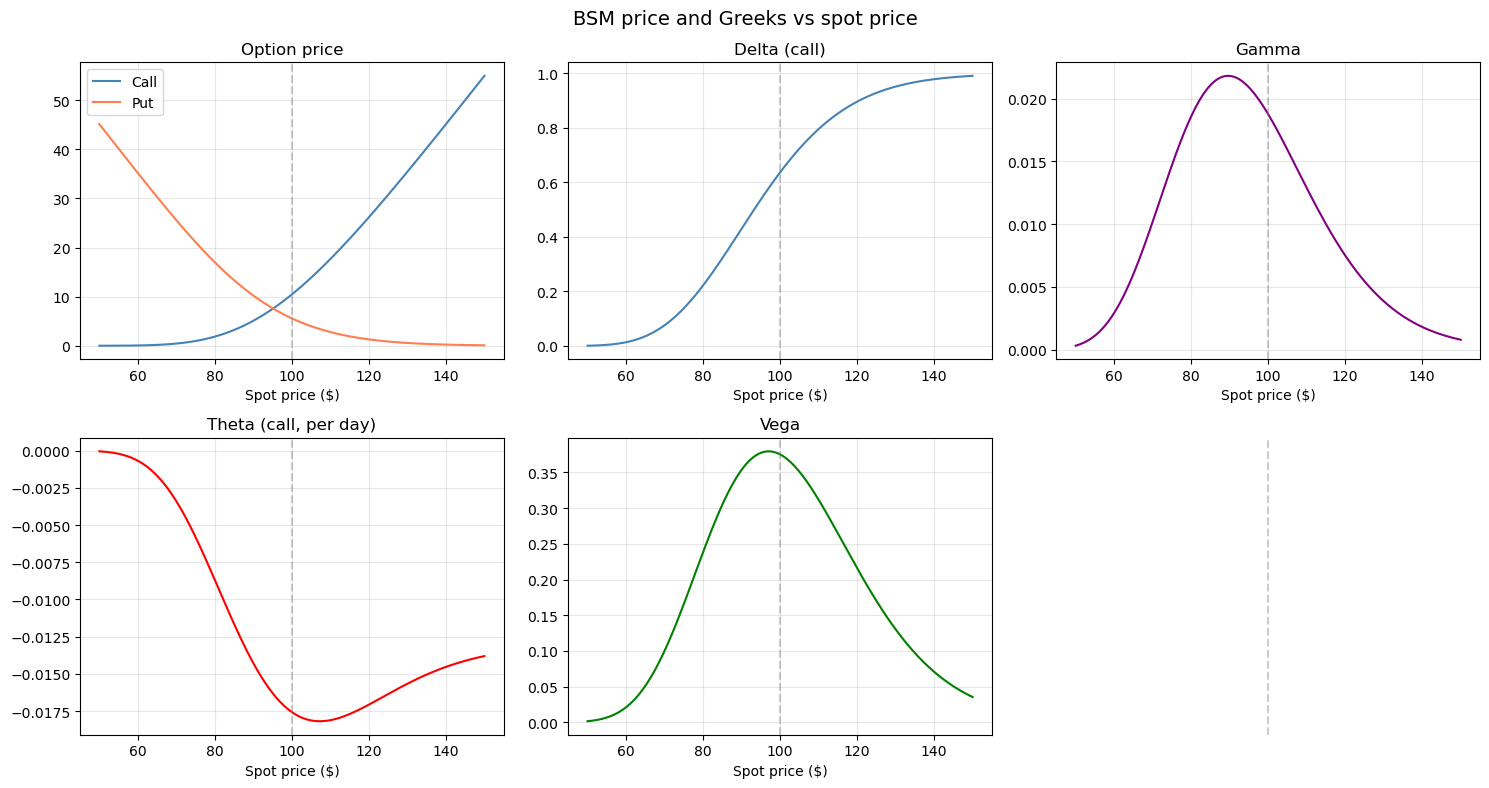

In [30]:
calls  = [bsm_price(s, K, T, r, sigma, "call") for s in S_range]
puts   = [bsm_price(s, K, T, r, sigma, "put")  for s in S_range]
deltas = [delta(s, K, T, r, sigma, "call") for s in S_range]
gammas = [gamma(s, K, T, r, sigma)         for s in S_range]
thetas = [theta(s, K, T, r, sigma, "call") for s in S_range]
vegas  = [vega(s, K, T, r, sigma)          for s in S_range]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("BSM price and Greeks vs spot price", fontsize=14)

axes[0,0].plot(S_range, calls, label="Call", color="steelblue")
axes[0,0].plot(S_range, puts,  label="Put",  color="coral")
axes[0,0].set_title("Option price"); axes[0,0].legend()

axes[0,1].plot(S_range, deltas, color="steelblue")
axes[0,1].set_title("Delta (call)")

axes[0,2].plot(S_range, gammas, color="purple")
axes[0,2].set_title("Gamma")

axes[1,0].plot(S_range, thetas, color="red")
axes[1,0].set_title("Theta (call, per day)")

axes[1,1].plot(S_range, vegas, color="green")
axes[1,1].set_title("Vega")

for ax in axes.flat:
    ax.axvline(K, linestyle="--", color="gray", alpha=0.4, label="Strike")
    ax.set_xlabel("Spot price ($)")
    ax.grid(alpha=0.3)

axes[1,2].axis("off")
plt.tight_layout()
plt.savefig("greeks_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Observations

### Option price
The call price increases with spot — as the stock rises, the right to buy at $100 
becomes more valuable. The put behaves inversely. Both curves are convex, reflecting 
the asymmetric payoff structure of options. They cross slightly below $100 because 
with r=0.05 the forward price sits above the spot strike.

### Delta
- At S=K=100, call delta is approximately 0.64
- With r=0.05 and T=1, the stock is expected to drift upward, so a call struck 
  at the current spot price already has a greater than 50% chance of finishing 
  in the money
- Deep in-the-money, delta approaches 1 — the option moves dollar-for-dollar 
  with the stock
- Far out-of-the-money, delta approaches 0

### Gamma
- Peaks to the left of the strike
- Measures how quickly delta changes — high gamma means your hedge needs 
  frequent rebalancing

### Theta
- Negative everywhere since options always lose time value as expiry approaches
- The minimum (most negative) point occurs slightly to the right of the gamma/vega 
  peak, because theta has an additional interest rate term that 
  shifts its minimum relative to gamma
- Recovers toward zero for deep in- or out-of-the-money options where there is 
  little time value left to decay

### Vega
- Peaks to the left of the strike
- Always positive for long options — higher volatility increases both calls and puts